###import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

###load dataset

In [2]:
df = pd.read_csv('analysis data.csv')

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 38451
Columns: 39


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38451 entries, 0 to 38450
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       38451 non-null  object 
 1   customer_id                    38451 non-null  object 
 2   order_status                   38451 non-null  object 
 3   order_purchase_timestamp       38451 non-null  object 
 4   order_approved_at              38451 non-null  object 
 5   order_delivered_carrier_date   38450 non-null  object 
 6   order_delivered_customer_date  38450 non-null  object 
 7   order_estimated_delivery_date  38450 non-null  object 
 8   customer_unique_id             38450 non-null  object 
 9   customer_zip_code_prefix       38450 non-null  float64
 10  customer_city                  38450 non-null  object 
 11  customer_state                 38450 non-null  object 
 12  order_item_id                  38450 non-null 

In [5]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,revenue,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,sao paulo,SP,0.0,Unknown,Unknown,2017-03-15 23:39:26,0.0,0.00,0.0,1.0,credit_card,1.0,18.12,Unknown,52.0,601.0,1.0,700.0,25.0,13.0,20.0,Unknown,2017.0,10.0,4.0,2.0,8.0,-8.0,On Time
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,sao paulo,SP,0.0,Unknown,Unknown,2017-03-15 23:39:26,0.0,0.00,0.0,3.0,voucher,1.0,2.00,Unknown,52.0,601.0,1.0,700.0,25.0,13.0,20.0,Unknown,2017.0,10.0,4.0,2.0,8.0,-8.0,On Time
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149.0,sao paulo,SP,0.0,Unknown,Unknown,2017-03-15 23:39:26,0.0,0.00,0.0,2.0,voucher,1.0,18.59,Unknown,52.0,601.0,1.0,700.0,25.0,13.0,20.0,Unknown,2017.0,10.0,4.0,2.0,8.0,-8.0,On Time
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813.0,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.7,22.76,118.7,1.0,boleto,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,2018.0,7.0,3.0,24.0,13.0,-6.0,On Time
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265.0,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.9,19.22,159.9,1.0,credit_card,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,2018.0,8.0,3.0,8.0,9.0,-18.0,On Time


In [6]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

,0
order_delivered_carrier_date,1
order_delivered_customer_date,1
order_estimated_delivery_date,1
customer_unique_id,1
customer_zip_code_prefix,1
customer_city,1
customer_state,1
order_item_id,1
product_id,1
seller_id,1


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


###total revenue

In [8]:
total_revenue = df['revenue'].sum()

print("Total Revenue:", round(total_revenue,2))

Total Revenue: 3835355.91


###Total customer

In [9]:
total_customers = df['customer_unique_id'].nunique()

print("Total Customers:", total_customers)

Total Customers: 32563


###Total orders

In [10]:
total_orders = df['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 32969


###Average order value

In [11]:
avg_order_value = (
    df['revenue'].sum()
    /
    df['order_id'].nunique()
)

print("Average Order Value:", round(avg_order_value,2))

Average Order Value: 116.33


###Top 10 states by Revenue

In [12]:
state_revenue = (
    df.groupby('customer_state')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_revenue

,revenue
customer_state,
SP,1458916.54
RJ,531132.81
MG,440922.72
RS,210528.72
PR,201682.27
SC,149199.94
BA,142369.97
GO,90519.52
DF,82665.55


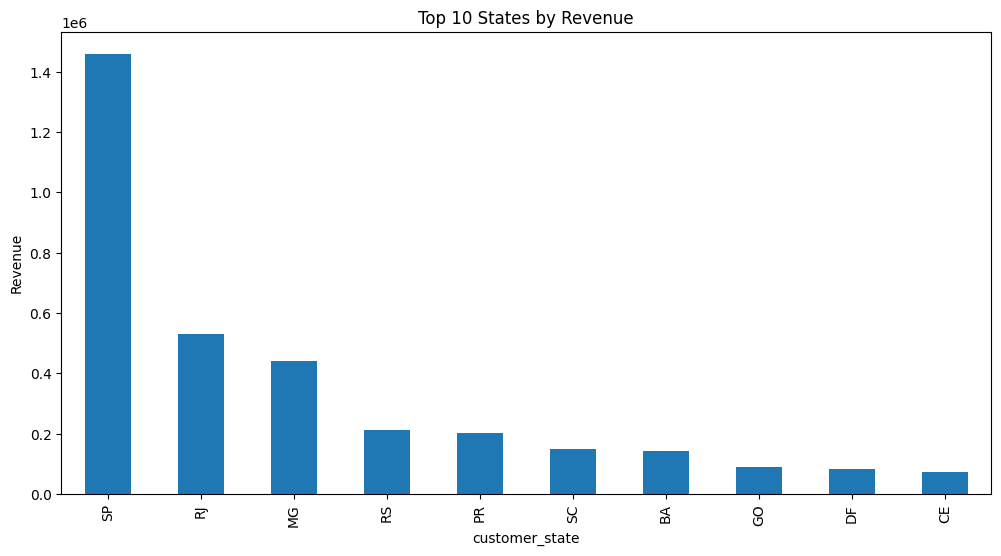

In [13]:
plt.figure(figsize=(12,6))

state_revenue.plot(kind='bar')

plt.title('Top 10 States by Revenue')
plt.ylabel('Revenue')

plt.show()

###Top 10 states by customers

In [14]:
state_customers = (
    df.groupby('customer_state')['customer_unique_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

state_customers

,customer_unique_id
customer_state,
SP,13785
RJ,4265
MG,3797
RS,1784
PR,1619
SC,1202
BA,1091
DF,659
ES,658


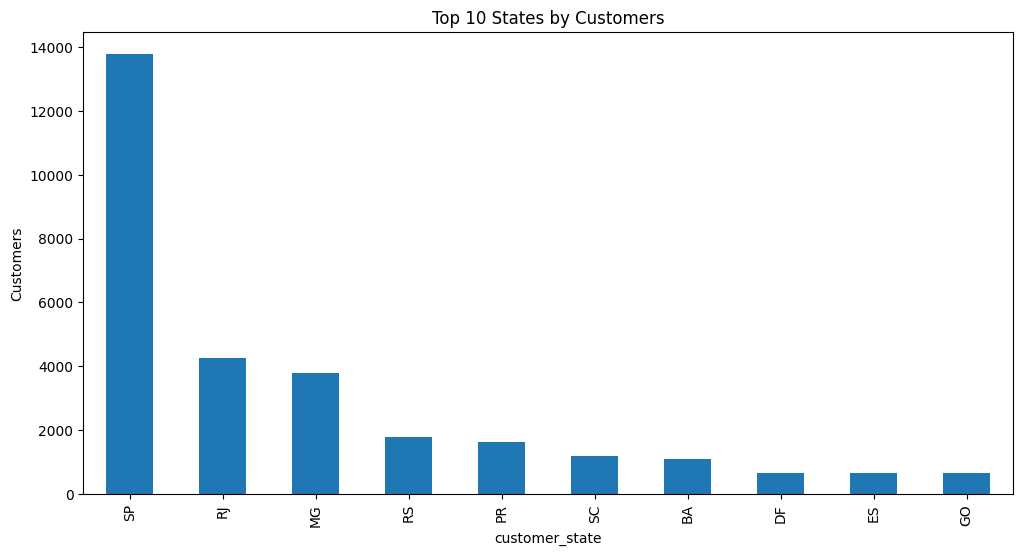

In [15]:
plt.figure(figsize=(12,6))

state_customers.plot(kind='bar')

plt.title('Top 10 States by Customers')
plt.ylabel('Customers')

plt.show()

###Monthly Revenue Trend

In [16]:
monthly_revenue = (
    df.groupby(
        ['purchase_year','purchase_month']
    )['revenue']
    .sum()
    .reset_index()
)

monthly_revenue['Period'] = (
    monthly_revenue['purchase_year'].astype(str)
    + '-'
    +
    monthly_revenue['purchase_month'].astype(str)
)

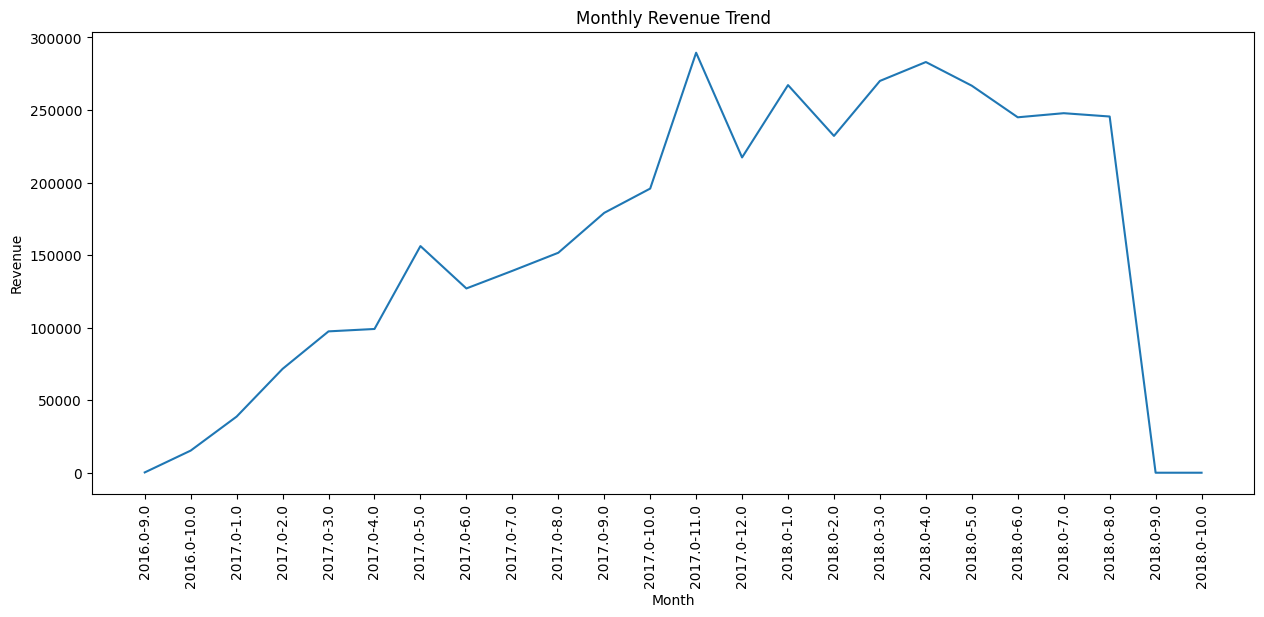

In [17]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_revenue['Period'],
    monthly_revenue['revenue']
)

plt.xticks(rotation=90)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

###Top categories by Revenue

In [18]:
category_revenue = (
    df.groupby('product_category_name_english')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

category_revenue

,revenue
product_category_name_english,
watches_gifts,350911.62
health_beauty,347161.22
bed_bath_table,296205.18
sports_leisure,265128.66
computers_accessories,258688.11
furniture_decor,209221.60
housewares,180989.40
cool_stuff,180222.25
auto,177537.07


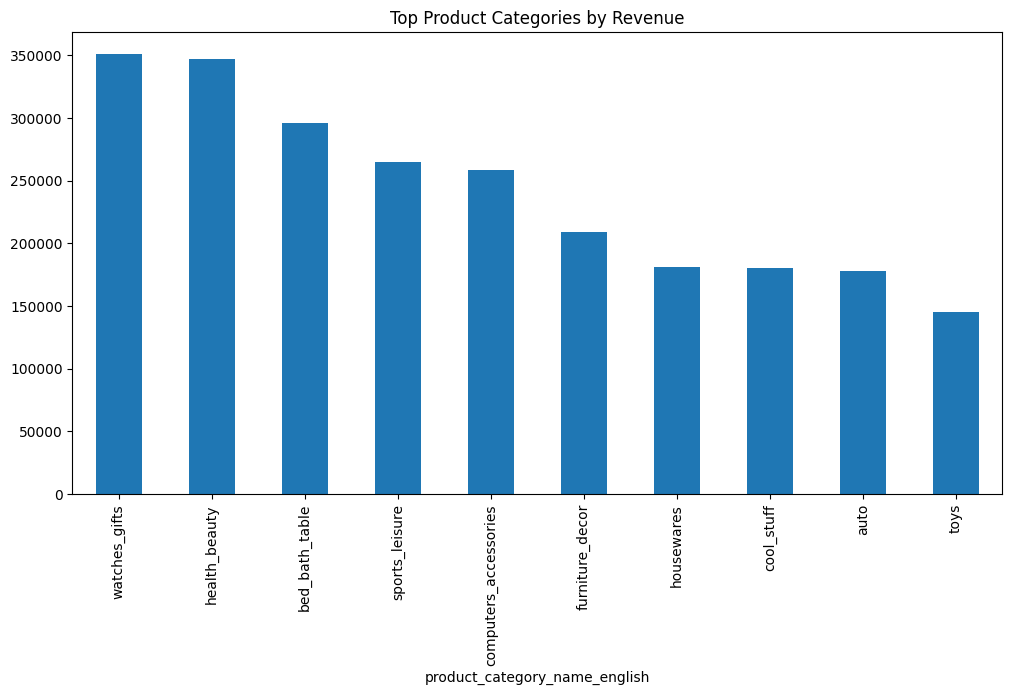

In [19]:
plt.figure(figsize=(12,6))

category_revenue.plot(kind='bar')

plt.title('Top Product Categories by Revenue')

plt.show()

###payment method analysis

In [20]:
payment_analysis = (
    df.groupby('payment_type')['revenue']
    .sum()
    .sort_values(ascending=False)
)

payment_analysis

,revenue
payment_type,
credit_card,2970216.31
boleto,646118.47
voucher,170518.82
debit_card,48367.34
unknown,134.97
not_defined,0.00


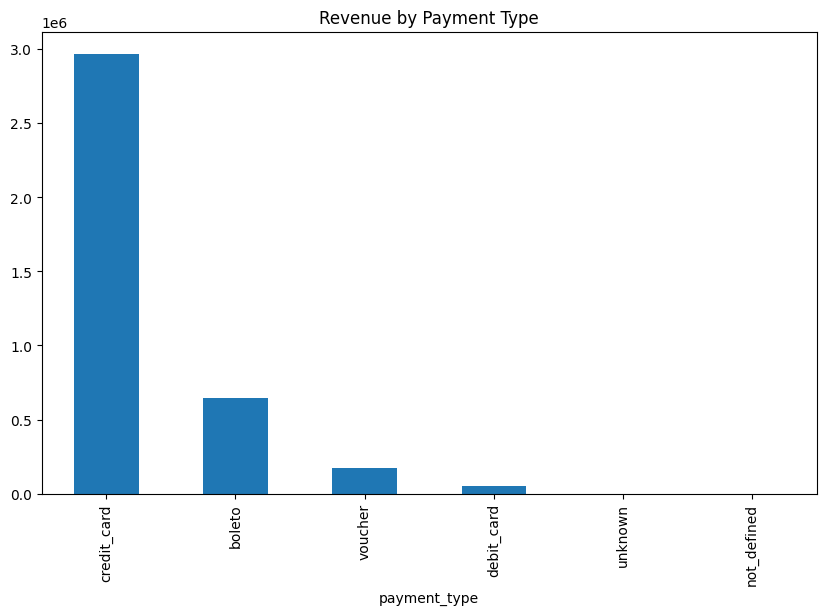

In [21]:
plt.figure(figsize=(10,6))

payment_analysis.plot(kind='bar')

plt.title('Revenue by Payment Type')

plt.show()

###Delivery status Distribution

In [22]:
delivery_analysis = (
    df.groupby('delivery_status')['order_id']
    .nunique()
)

delivery_analysis

,order_id
delivery_status,
Delayed,2143
On Time,30825


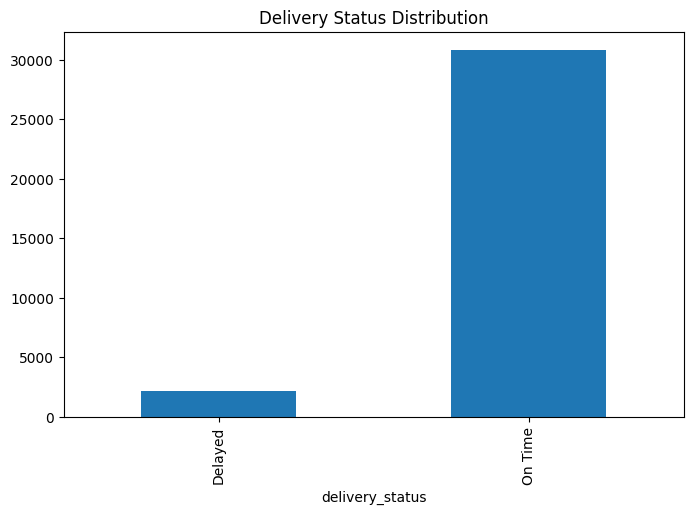

In [23]:
plt.figure(figsize=(8,5))

delivery_analysis.plot(kind='bar')

plt.title('Delivery Status Distribution')

plt.show()

In [24]:
avg_delay = df['delivery_delay'].mean()

print("Average Delivery Delay:", round(avg_delay,2))

Average Delivery Delay: -12.02


In [27]:
ontime_deliveries = df[df['delivery_status'] == 'On Time'].shape[0]
total_deliveries = df.shape[0]

# Calculate the percentage of on-time deliveries, handling division by zero
if total_deliveries > 0:
    percentage_ontime = (ontime_deliveries / total_deliveries) * 100
else:
    percentage_ontime = 0

print("Percentage of On-time Deliveries:", round(percentage_ontime, 2), "%")

Percentage of On-time Deliveries: 93.7 %


In [25]:
summary = pd.DataFrame({
    'KPI':[
        'Total Revenue',
        'Total Customers',
        'Total Orders',
        'Average Order Value',
        'Average Delivery Delay'
    ],
    'Value':[
        round(total_revenue,2),
        total_customers,
        total_orders,
        round(avg_order_value,2),
        round(avg_delay,2)
    ]
})

summary

,KPI,Value
0,Total Revenue,3835355.91
1,Total Customers,32563.00
2,Total Orders,32969.00
3,Average Order Value,116.33
4,Average Delivery Delay,-12.02
